# DLinear vs. TimeMixer vs. TimeXer vs. iTransformer vs. your Tensor-AR pipeline (M4)

This notebook runs **your existing pipeline** (PARAFAC tensor decomposition + per-factor `AutoReg`)
side-by-side with **DLinear**, **iTransformer**, **TimeXer**, and **TimeMixer** on the *exact same*
data slice, split, and metrics, so the numbers are directly comparable.

**What's kept identical to your `m4.ipynb`:**
- Same 5 series selected from `Monthly-train.csv` (`df.iloc[13:18, 1:PERIOD*TIME+1]`)
- Same `(PERIOD=25, TIME=12, FEATURES=5)` reshape
- Same `TRAIN_DAYS=20` / `TEST_DAYS=5` split (240 train steps, 60 test steps)
- Same evaluation metrics: R², MSE, MAE, RMSE, computed **per feature** on the 60 held-out steps

**What has to differ:**
- Your tensor-AR method fits directly on the single 20-period series (no separate training set needed
  — it's decomposition + a tiny autoregressive model on the latent factors).
- The four learned models (DLinear, iTransformer, TimeXer, TimeMixer) are supervised
  `seq_len -> pred_len` regressors, so each needs multiple example windows to learn from. Those
  windows are cut **only** from the 240 training steps (sliding windows), and the 60 test steps are
  only ever used once, at the very end, for scoring — never for fitting. So the comparison stays
  apples-to-apples: every model only ever sees the same 240 training points before being scored on
  the same held-out 60 points.

**On the three new models.** `TimeMixer.py`, `TimeXer.py`, and `iTransformer.py` (as you uploaded
them) depend on this repo's shared `layers/` package (`Embed`, `SelfAttention_Family`,
`Transformer_EncDec`, `Autoformer_EncDec`, `StandardNorm`), which isn't installed in this notebook's
environment. Rather than vendor that whole package, each model below is a **self-contained
re-implementation that preserves its defining architectural idea**, sized down for this 5-channel,
240-point dataset:

| Model | Core idea kept | Simplified away |
|---|---|---|
| **iTransformer** | Each *variate's whole series* is embedded as one token; self-attention runs *across variates*, not across time; per-instance mean/std normalization | Multivariate covariates/timestamp embedding (`x_mark`) — not present in this dataset anyway |
| **TimeXer** | Endogenous variable is patch-embedded with a learned global token; self-attention over patches; the global token then cross-attends to inverted (whole-series) embeddings of *all* variates | Timestamp features in the exogenous embedding; only one encoder block by default |
| **TimeMixer** | Input is decomposed (moving-average) at multiple down-sampled scales; seasonal parts are mixed bottom-up (fine→coarse), trend parts top-down (coarse→fine); each scale gets its own predictor and predictions are summed | The learned `d_model` embedding step and timestamp features — mixing happens directly in the (channel-independent) raw signal space, closer in spirit to how DLinear operates |

This keeps every model runnable with just `torch`, and keeps the comparison about the *architectural
idea* (variate-attention vs. patch+cross-attention vs. multi-scale decomposition vs. plain
decomposition-linear vs. tensor decomposition), rather than about which repo's boilerplate happens to
be installed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

np.random.seed(2023)
torch.manual_seed(2023)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Data loading — identical to your notebook

In [2]:
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = 12   # if monthly --> 12, else if daily --> 24
FEATURES = 5

df = pd.read_csv("./dataset/m4/Train/Monthly-train.csv")

# same 5 series as your notebook
df_selected = df.iloc[13:18, 1:PERIOD * TIME + 1]
df = df_selected.T

data = df[df.columns.to_list()][:PERIOD * TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES).astype(np.float64)

train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS + TEST_DAYS, :, :]

# flattened (time, features) views used by every model below
train_series = train_tensor.reshape(-1, FEATURES).astype(np.float32)   # (240, 5)
test_series = test_tensor.reshape(-1, FEATURES).astype(np.float32)     # (60, 5)

print("train_series:", train_series.shape, " test_series:", test_series.shape)


train_series: (240, 5)  test_series: (60, 5)


## 2. Baseline — your Tensor Decomposition + AR pipeline

Condensed re-run of your existing cells (PARAFAC rank-2 decomposition, `AutoReg(lags=1)` on each
latent day-factor, tensor reconstruction) so its forecast is available for the comparison table below.


In [3]:
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
from statsmodels.tsa.ar_model import AutoReg

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
day_factors, time_factors, feature_factors = factors

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    ar_model = AutoReg(series, lags=1, old_names=False)
    ar_fit = ar_model.fit()
    forecast_day_factors[:, r] = ar_fit.forecast(steps=TEST_DAYS)

forecast_tensor_ar = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor_ar[i, :, :] += weights[r] * np.outer(
            forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r]
        )

forecast_series_ar = forecast_tensor_ar.reshape(-1, FEATURES).astype(np.float32)  # (60, 5)
print("Tensor-AR forecast shape:", forecast_series_ar.shape)


Tensor-AR forecast shape: (60, 5)


## 3. Shared setup for the four learned models

All four learned models below use the **same** input/output window sizes and the **same** training
windows, cut only from `train_series`, so their comparison to each other (and to Tensor-AR) is on
equal footing.


In [4]:
SEQ_LEN = 60              # input window length
PRED_LEN = TEST_DAYS * TIME  # 60, must match the held-out horizon

def build_windows(series, seq_len, pred_len):
    """All sliding (input, target) windows fully inside `series`."""
    X, Y = [], []
    T = series.shape[0]
    for start in range(0, T - seq_len - pred_len + 1):
        X.append(series[start:start + seq_len])
        Y.append(series[start + seq_len:start + seq_len + pred_len])
    return np.stack(X), np.stack(Y)

X_train, Y_train = build_windows(train_series, SEQ_LEN, PRED_LEN)
print(f"Training windows: {X_train.shape[0]} (each {SEQ_LEN} -> {PRED_LEN}, {FEATURES} channels)")

X_train_t = torch.from_numpy(X_train).float().to(device)
Y_train_t = torch.from_numpy(Y_train).float().to(device)
last_window_t = torch.from_numpy(train_series[-SEQ_LEN:]).float().unsqueeze(0).to(device)  # for final forecast

def train_model(model, epochs=500, lr=1e-3, log_every=100, name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, Y_train_t)
        loss.backward()
        optimizer.step()
        if epoch % log_every == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:04d} | train MSE {loss.item():.4f}")
    model.eval()
    with torch.no_grad():
        forecast = model(last_window_t).squeeze(0).cpu().numpy()
    return model, forecast


Training windows: 121 (each 60 -> 60, 5 channels)


### 4a. DLinear

In [5]:
class moving_avg(nn.Module):
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)


class series_decomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class DLinear(nn.Module):
    """Multivariate DLinear (channels shared, individual=False — matches the paper's default)."""
    def __init__(self, seq_len, pred_len, channels, moving_avg_kernel=25):
        super().__init__()
        self.decompsition = series_decomp(moving_avg_kernel)
        self.Linear_Seasonal = nn.Linear(seq_len, pred_len)
        self.Linear_Trend = nn.Linear(seq_len, pred_len)
        with torch.no_grad():
            self.Linear_Seasonal.weight.copy_((1 / seq_len) * torch.ones(pred_len, seq_len))
            self.Linear_Trend.weight.copy_((1 / seq_len) * torch.ones(pred_len, seq_len))

    def forward(self, x):
        # x: [B, seq_len, C]
        seasonal_init, trend_init = self.decompsition(x)
        seasonal_init, trend_init = seasonal_init.permute(0, 2, 1), trend_init.permute(0, 2, 1)
        seasonal_output = self.Linear_Seasonal(seasonal_init)
        trend_output = self.Linear_Trend(trend_init)
        out = seasonal_output + trend_output          # [B, C, pred_len]
        return out.permute(0, 2, 1)                    # [B, pred_len, C]


dlinear_model, forecast_series_dlinear = train_model(
    DLinear(SEQ_LEN, PRED_LEN, FEATURES, moving_avg_kernel=25),
    epochs=500, lr=1e-3, name="DLinear"
)
print("DLinear forecast shape:", forecast_series_dlinear.shape)


[DLinear] Epoch 0001 | train MSE 675366.6250
[DLinear] Epoch 0100 | train MSE 17357.1172
[DLinear] Epoch 0200 | train MSE 15886.9619
[DLinear] Epoch 0300 | train MSE 15023.0635
[DLinear] Epoch 0400 | train MSE 14249.0186
[DLinear] Epoch 0500 | train MSE 13516.6074
DLinear forecast shape: (60, 5)


### 4b. iTransformer

Core idea (Liu et al., 2024): flip what a "token" is. Instead of one token per time step, each
**variate's entire series** becomes one token (via a `Linear(seq_len, d_model)` "inverted"
embedding). Self-attention then runs across the *N* variate-tokens, learning cross-variate
correlations directly, followed by per-variate instance normalization and a linear projection
to `pred_len`.


In [6]:
class DataEmbeddingInverted(nn.Module):
    def __init__(self, seq_len, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding = nn.Linear(seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):  # x: [B, L, N]
        x = x.permute(0, 2, 1)              # [B, N, L]
        return self.dropout(self.value_embedding(x))  # [B, N, d_model]


class ITransformer(nn.Module):
    def __init__(self, seq_len, pred_len, n_vars, d_model=32, n_heads=4, e_layers=2, d_ff=64, dropout=0.1):
        super().__init__()
        self.pred_len = pred_len
        self.enc_embedding = DataEmbeddingInverted(seq_len, d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation="gelu", batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=e_layers)
        self.projection = nn.Linear(d_model, pred_len)

    def forward(self, x):  # x: [B, seq_len, N]
        means = x.mean(1, keepdim=True).detach()          # [B, 1, N]
        x = x - means
        stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + 1e-5)
        x = x / stdev

        enc_out = self.enc_embedding(x)     # [B, N, d_model]  (N tokens, one per variate)
        enc_out = self.encoder(enc_out)     # attention runs ACROSS variates
        dec_out = self.projection(enc_out)  # [B, N, pred_len]
        dec_out = dec_out.permute(0, 2, 1)  # [B, pred_len, N]

        dec_out = dec_out * stdev.repeat(1, self.pred_len, 1)
        dec_out = dec_out + means.repeat(1, self.pred_len, 1)
        return dec_out


itransformer_model, forecast_series_itransformer = train_model(
    ITransformer(SEQ_LEN, PRED_LEN, FEATURES, d_model=32, n_heads=4, e_layers=2, d_ff=64, dropout=0.1),
    epochs=500, lr=1e-3, name="iTransformer"
)
print("iTransformer forecast shape:", forecast_series_itransformer.shape)


[iTransformer] Epoch 0001 | train MSE 717806.3125
[iTransformer] Epoch 0100 | train MSE 84976.8906
[iTransformer] Epoch 0200 | train MSE 39156.0391
[iTransformer] Epoch 0300 | train MSE 21743.8926
[iTransformer] Epoch 0400 | train MSE 14978.4951
[iTransformer] Epoch 0500 | train MSE 12020.7744
iTransformer forecast shape: (60, 5)


### 4c. TimeXer

Core idea (Wang et al., 2024): each variate is **patch-embedded** (split into fixed-length patches,
each linearly projected) plus one learned **global token**; self-attention runs over a variate's own
patches + global token. The global token then **cross-attends** to inverted (whole-series) embeddings
of all variates, injecting cross-variate context without patching every variate against every other.
A flatten head maps `(patch_num + 1) * d_model -> pred_len`.


In [7]:
class TimeXer(nn.Module):
    def __init__(self, seq_len, pred_len, n_vars, patch_len=12, d_model=32, n_heads=4,
                 e_layers=1, d_ff=64, dropout=0.1):
        super().__init__()
        assert seq_len % patch_len == 0, "seq_len must be divisible by patch_len"
        self.patch_len = patch_len
        self.patch_num = seq_len // patch_len
        self.n_vars = n_vars
        self.pred_len = pred_len
        self.d_model = d_model

        self.value_embedding = nn.Linear(patch_len, d_model)
        self.glb_token = nn.Parameter(torch.randn(1, n_vars, 1, d_model) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.patch_num + 1, d_model) * 0.02)
        self.ex_embedding = nn.Linear(seq_len, d_model)  # inverted (whole-series) embedding

        self.self_attn = nn.ModuleList(
            [nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True) for _ in range(e_layers)])
        self.cross_attn = nn.ModuleList(
            [nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True) for _ in range(e_layers)])
        self.ffn = nn.ModuleList(
            [nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)) for _ in range(e_layers)])
        self.norm1 = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(e_layers)])
        self.norm2 = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(e_layers)])
        self.norm3 = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(e_layers)])
        self.e_layers = e_layers
        self.dropout = nn.Dropout(dropout)

        self.head = nn.Linear(d_model * (self.patch_num + 1), pred_len)

    def forward(self, x):  # x: [B, seq_len, N]
        B, L, N = x.shape
        means = x.mean(1, keepdim=True).detach()           # [B, 1, N]
        x = x - means
        stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + 1e-5)
        x_norm = x / stdev

        # endogenous: patch-embed every variate independently
        xp = x_norm.permute(0, 2, 1)                        # [B, N, L]
        xp = xp.unfold(-1, self.patch_len, self.patch_len)  # [B, N, patch_num, patch_len]
        xp = xp.reshape(B * N, self.patch_num, self.patch_len)
        patch_embed = self.value_embedding(xp)               # [B*N, patch_num, d_model]
        glb = self.glb_token.repeat(B, 1, 1, 1).reshape(B * N, 1, self.d_model)
        en = torch.cat([patch_embed, glb], dim=1) + self.pos_embedding   # [B*N, patch_num+1, d_model]
        en = self.dropout(en)

        # exogenous: whole-series-as-token embedding for every variate (cross context)
        ex = self.ex_embedding(x_norm.permute(0, 2, 1))       # [B, N, d_model]
        ex_kv = ex.unsqueeze(1).repeat(1, N, 1, 1).reshape(B * N, N, self.d_model)  # keys/values per query

        for i in range(self.e_layers):
            attn_out, _ = self.self_attn[i](en, en, en)
            en = self.norm1[i](en + attn_out)

            glb_tok = en[:, -1:, :]                              # [B*N, 1, d_model]
            cross_out, _ = self.cross_attn[i](glb_tok, ex_kv, ex_kv)
            glb_tok = self.norm2[i](glb_tok + cross_out)
            en = torch.cat([en[:, :-1, :], glb_tok], dim=1)

            en = self.norm3[i](en + self.ffn[i](en))

        out = self.head(en.reshape(B * N, -1))    # [B*N, pred_len]
        out = out.reshape(B, N, self.pred_len).permute(0, 2, 1)   # [B, pred_len, N]

        out = out * stdev.repeat(1, self.pred_len, 1)
        out = out + means.repeat(1, self.pred_len, 1)
        return out


timexer_model, forecast_series_timexer = train_model(
    TimeXer(SEQ_LEN, PRED_LEN, FEATURES, patch_len=12, d_model=32, n_heads=4, e_layers=1, d_ff=64, dropout=0.1),
    epochs=500, lr=1e-3, name="TimeXer"
)
print("TimeXer forecast shape:", forecast_series_timexer.shape)


[TimeXer] Epoch 0001 | train MSE 686793.4375
[TimeXer] Epoch 0100 | train MSE 32304.9160
[TimeXer] Epoch 0200 | train MSE 22503.2500
[TimeXer] Epoch 0300 | train MSE 9138.7344
[TimeXer] Epoch 0400 | train MSE 6721.6494
[TimeXer] Epoch 0500 | train MSE 5432.7651
TimeXer forecast shape: (60, 5)


### 4d. TimeMixer

Core idea (Wang et al., 2024): decompose the input at **multiple down-sampled scales**
(full resolution, half, quarter, ...) via moving-average `series_decomp`. Seasonal parts are mixed
**bottom-up** (fine scale informs coarser scales), trend parts are mixed **top-down** (coarse scale
informs finer scales) — the opposite mixing directions reflect that high-frequency seasonal detail is
best captured at fine resolution while trend is best captured at coarse resolution. Every scale gets
its own small predictor `Linear(L_i, pred_len)`, and the final forecast sums all scales' predictions
(a lightweight ensemble across resolutions).


In [8]:
class TimeMixer(nn.Module):
    def __init__(self, seq_len, pred_len, n_vars, moving_avg_kernel=5,
                 down_sampling_window=2, down_sampling_layers=2):
        super().__init__()
        assert seq_len % (down_sampling_window ** down_sampling_layers) == 0, \
            "seq_len must be evenly divisible by down_sampling_window ** down_sampling_layers"
        self.pred_len = pred_len
        self.down_sampling_window = down_sampling_window
        self.down_sampling_layers = down_sampling_layers
        self.decomp = series_decomp(moving_avg_kernel)

        self.scale_lens = [seq_len // (down_sampling_window ** i) for i in range(down_sampling_layers + 1)]

        # bottom-up season mixing: L_i -> L_{i+1}  (fine -> coarse)
        self.season_mix = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.scale_lens[i], self.scale_lens[i + 1]), nn.GELU(),
                nn.Linear(self.scale_lens[i + 1], self.scale_lens[i + 1]),
            ) for i in range(down_sampling_layers)
        ])
        # top-down trend mixing: L_{i+1} -> L_i  (coarse -> fine)
        self.trend_mix = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.scale_lens[i + 1], self.scale_lens[i]), nn.GELU(),
                nn.Linear(self.scale_lens[i], self.scale_lens[i]),
            ) for i in reversed(range(down_sampling_layers))
        ])
        # per-scale predictors, summed at the end
        self.predictors = nn.ModuleList([nn.Linear(L, pred_len) for L in self.scale_lens])

    def forward(self, x):  # x: [B, seq_len, N]
        B, L, N = x.shape
        x_ci = x.permute(0, 2, 1).reshape(B * N, L, 1)   # channel-independent: [B*N, L, 1]

        # multi-scale pyramid via average pooling
        scales = [x_ci]
        cur = x_ci
        for _ in range(self.down_sampling_layers):
            cur = F.avg_pool1d(cur.permute(0, 2, 1), kernel_size=self.down_sampling_window,
                                stride=self.down_sampling_window).permute(0, 2, 1)
            scales.append(cur)

        season_list, trend_list = [], []
        for s in scales:
            season, trend = self.decomp(s)               # each [B*N, L_i, 1]
            season_list.append(season.permute(0, 2, 1))  # [B*N, 1, L_i]
            trend_list.append(trend.permute(0, 2, 1))

        # bottom-up season mixing (fine -> coarse)
        out_season = [season_list[0]]
        cur_season = season_list[0]
        for i in range(self.down_sampling_layers):
            cur_season = season_list[i + 1] + self.season_mix[i](cur_season)
            out_season.append(cur_season)

        # top-down trend mixing (coarse -> fine)
        trend_rev = list(reversed(trend_list))
        out_trend_rev = [trend_rev[0]]
        cur_trend = trend_rev[0]
        for i in range(self.down_sampling_layers):
            cur_trend = trend_rev[i + 1] + self.trend_mix[i](cur_trend)
            out_trend_rev.append(cur_trend)
        out_trend = list(reversed(out_trend_rev))

        preds = 0
        for i in range(len(self.scale_lens)):
            combined = out_season[i] + out_trend[i]        # [B*N, 1, L_i]
            preds = preds + self.predictors[i](combined)   # [B*N, 1, pred_len]

        preds = preds.squeeze(1)                            # [B*N, pred_len]
        preds = preds.reshape(B, N, self.pred_len).permute(0, 2, 1)  # [B, pred_len, N]
        return preds


timemixer_model, forecast_series_timemixer = train_model(
    TimeMixer(SEQ_LEN, PRED_LEN, FEATURES, moving_avg_kernel=5, down_sampling_window=2, down_sampling_layers=2),
    epochs=500, lr=1e-3, name="TimeMixer"
)
print("TimeMixer forecast shape:", forecast_series_timemixer.shape)


[TimeMixer] Epoch 0001 | train MSE 25133452.0000
[TimeMixer] Epoch 0100 | train MSE 43337.8398
[TimeMixer] Epoch 0200 | train MSE 36975.8281
[TimeMixer] Epoch 0300 | train MSE 29080.1680
[TimeMixer] Epoch 0400 | train MSE 23988.2617
[TimeMixer] Epoch 0500 | train MSE 21184.4531
TimeMixer forecast shape: (60, 5)


## 5. Side-by-side metrics

Same metrics as your notebook (`r2_score`, `mean_squared_error`, `mean_absolute_error`,
`root_mean_squared_error`), computed per feature for every forecast against the same `test_series`.


In [9]:
forecasts = {
    "Tensor-AR (yours)": forecast_series_ar,
    "DLinear": forecast_series_dlinear,
    "iTransformer": forecast_series_itransformer,
    "TimeXer": forecast_series_timexer,
    "TimeMixer": forecast_series_timemixer,
}

rows = []
for i in range(FEATURES):
    actual = test_series[:, i]
    for method_name, forecast in forecasts.items():
        rows.append({
            "Feature": i,
            "Method": method_name,
            "R2": r2_score(actual, forecast[:, i]),
            "MSE": mean_squared_error(actual, forecast[:, i]),
            "MAE": mean_absolute_error(actual, forecast[:, i]),
            "RMSE": root_mean_squared_error(actual, forecast[:, i]),
        })

results_df = pd.DataFrame(rows).sort_values(["Feature", "Method"]).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
results_df


,Feature,Method,R2,MSE,MAE,RMSE
0,0,DLinear,-1.0559,54812.9609,204.2809,234.1217
1,0,Tensor-AR (yours),0.7352,7061.2412,65.6455,84.0312
2,0,TimeMixer,-1.0360,54284.0547,200.8214,232.9894
3,0,TimeXer,-0.2449,33190.7461,143.8661,182.1833
4,0,iTransformer,0.8011,5302.1797,57.1916,72.8161
5,1,DLinear,0.4783,7639.3389,79.6140,87.4033
6,1,Tensor-AR (yours),0.7811,3205.2571,44.5417,56.6150
7,1,TimeMixer,0.5773,6189.4810,69.2626,78.6733
8,1,TimeXer,0.9078,1350.8082,29.5225,36.7533
9,1,iTransformer,0.9524,696.3017,21.9175,26.3875


In [10]:
# Overall (macro-averaged across the 5 features) comparison, ranked by MSE
summary = results_df.groupby("Method")[["R2", "MSE", "MAE", "RMSE"]].mean()
summary.sort_values("MSE")


,R2,MSE,MAE,RMSE
Method,,,,
Tensor-AR (yours),0.5299,60380.2509,166.0710,196.1321
iTransformer,0.0393,140780.0974,248.3457,284.4624
DLinear,-0.5376,174938.1189,306.2639,347.3263
TimeMixer,-0.9222,231594.1610,345.1679,395.4981
TimeXer,-1.8137,398207.1187,425.7509,494.3947


## 6. Overlaid forecast plots

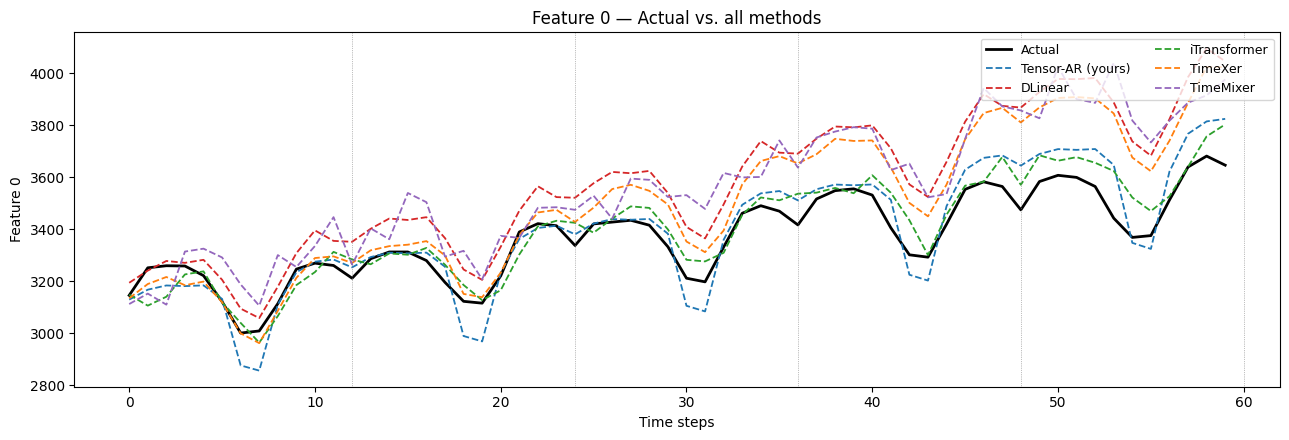

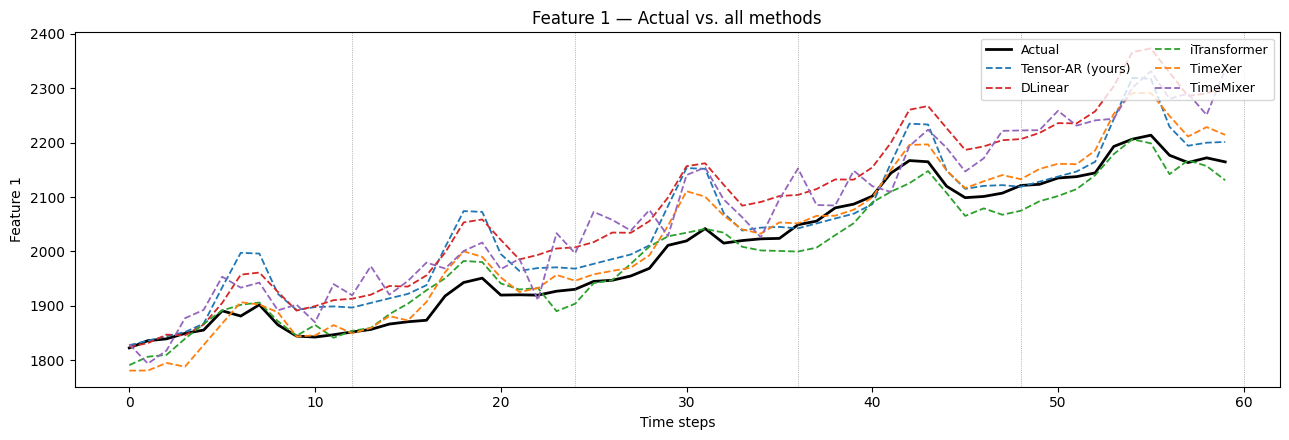

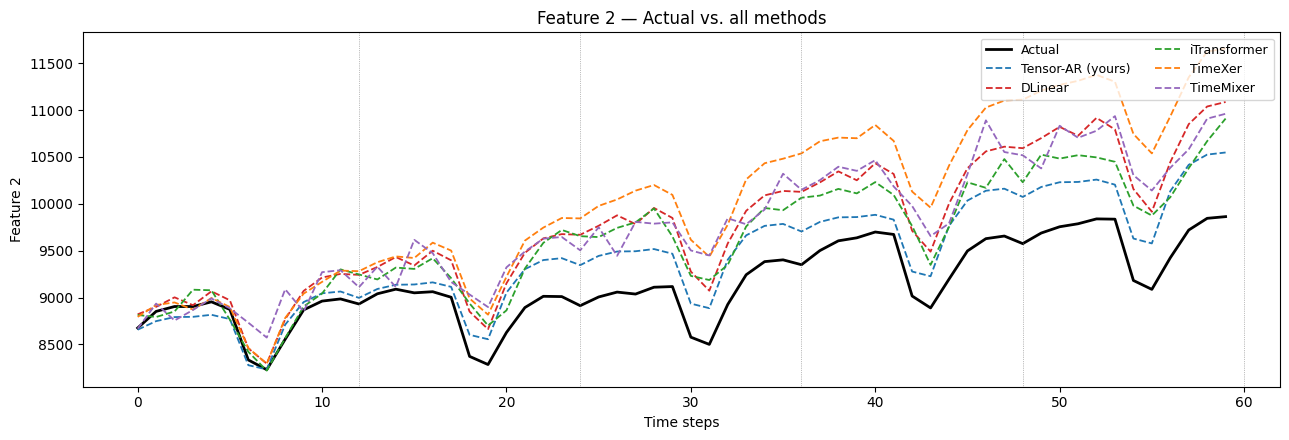

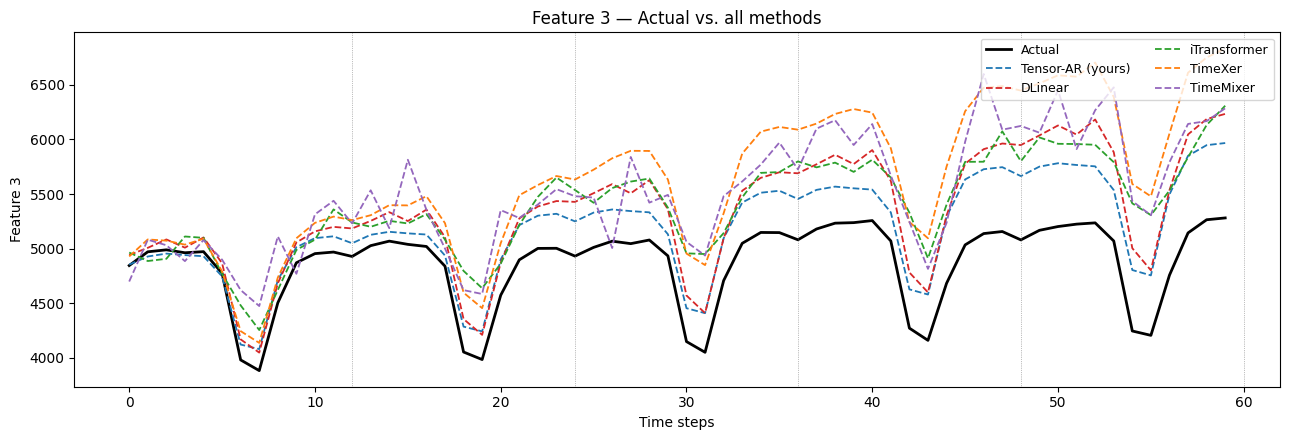

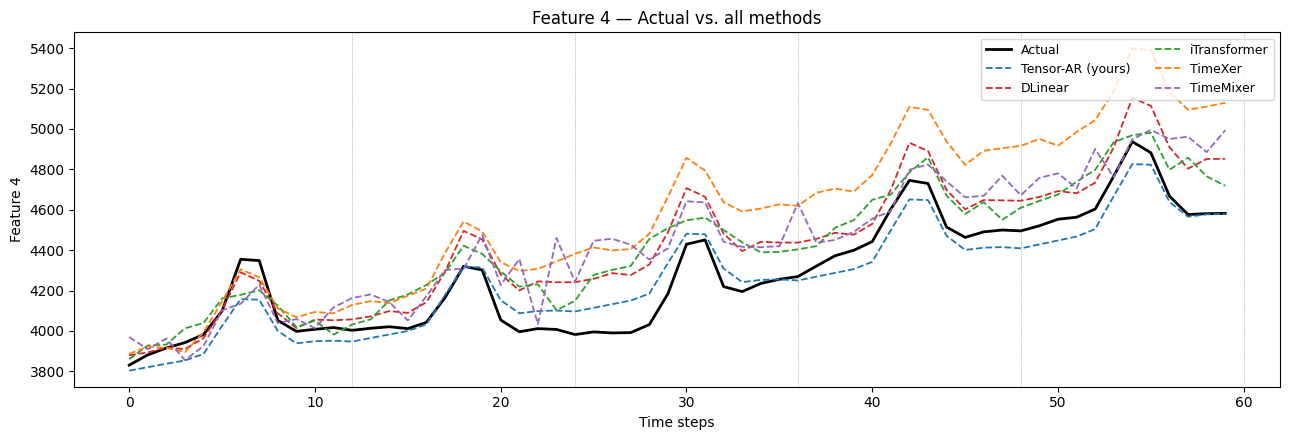

In [11]:
x = np.arange(TEST_DAYS * TIME)
colors = {
    "Tensor-AR (yours)": "tab:blue",
    "DLinear": "tab:red",
    "iTransformer": "tab:green",
    "TimeXer": "tab:orange",
    "TimeMixer": "tab:purple",
}

for i in range(FEATURES):
    plt.figure(figsize=(13, 4.5))
    plt.plot(x, test_series[:, i], 'k-', lw=2, label='Actual')
    for method_name, forecast in forecasts.items():
        plt.plot(x, forecast[:, i], '--', lw=1.3, color=colors[method_name], label=method_name)
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Feature {i} — Actual vs. all methods')
    plt.xlabel('Time steps')
    plt.ylabel(f'Feature {i}')
    plt.legend(loc='upper right', ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


## Notes on interpreting this comparison

- **Training data volume differs by design, not by unfairness.** The tensor-AR approach only ever
  needs the 240 raw points (rank-2 decomposition + AR(1) on 2 latent series of length 20). The four
  learned models are supervised regressors and are trained on overlapping windows *carved only from
  those same 240 points* — the 60 test points are never seen until each model's final
  forecast/scoring step.
- **This is a very small-data regime** (5 series, 240 train points, 121 training windows). All four
  learned models here are attention/mixing architectures designed for tens of thousands of training
  windows; at this scale, expect DLinear (fewest parameters, strongest inductive bias) to be
  competitive with or beat the larger models, and expect run-to-run variance in the attention-based
  models to be non-trivial. Re-running with a different `torch.manual_seed` is a good sanity check
  before drawing conclusions.
- **Model capacity knobs** (`d_model`, `n_heads`, `e_layers`, `patch_len`, `down_sampling_window`,
  `down_sampling_layers`) are all exposed in each model's constructor above — worth a small sweep if
  one architecture looks like it's underfitting vs. overfitting relative to the others.
- If you want everything scored the way the M4 competition itself scores forecasts (SMAPE/MASE/OWA
  instead of R²/MSE/MAE/RMSE), see the `DLinear_M4.ipynb` notebook from earlier — it implements those
  metrics directly and could be extended with the same model classes defined here.
